In [187]:

# Settings for the iterative procedure
n_steps = 100               # number of sloppy steps to take
step_size = 1          # step size in log-parameter space along sloppy direction
tol_positive_eig = -5    # threshold to consider eigenvalue as positive
sloppy_threshold = 1e-3     # threshold for identifying sloppy eigenvectors

RANDOM_STARTING_POINT = False  # If True, multiply each parameter by a random factor from {1/8,...,8}

# Multi-vector stepping and noise settings
MULT = False   # If True, sample one sloppy mode with log-sloppiness weights; if False, use a weighted sloppy-mode combination
              # If False, always use the most sloppy (smallest eigenvalue) vector
NOISE = 1e-2   # Variance of Gaussian noise added to step vector (0 = no noise)
NOK3  = True  # if True, exclude k3_CT from param_names


Eigenvalues (descending):
 1: 8.187e+00
 2: 1.015e-01
 3: 3.544e-04
 4: 2.743e-04
 5: 1.353e-04


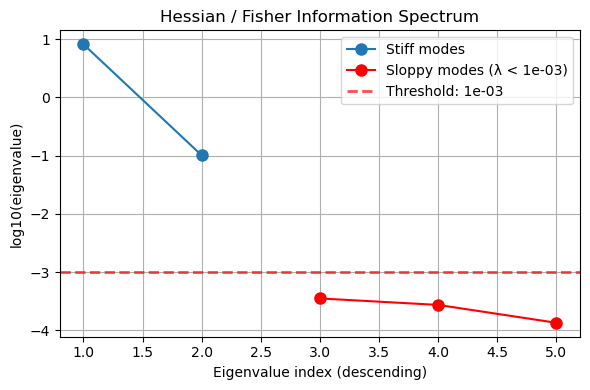


Eigenvector 1 (lambda=8.187e+00):
    k1_aa_over_CT: -0.589
               k4: -0.417
          k4prime: -0.186
               k6: +0.667
               k7: -0.000

Eigenvector 2 (lambda=1.015e-01):
    k1_aa_over_CT: -0.772
               k4: +0.274
          k4prime: +0.415
               k6: -0.395
               k7: +0.004

Eigenvector 3 (lambda=3.544e-04):
    k1_aa_over_CT: -0.233
               k4: +0.181
          k4prime: -0.874
               k6: -0.337
               k7: -0.186

Eigenvector 4 (lambda=2.743e-04):
    k1_aa_over_CT: -0.042
               k4: -0.012
          k4prime: -0.166
               k6: -0.090
               k7: +0.981
eigvals sorted (desc): [8.18668815e+00 1.01471894e-01 3.54427834e-04 2.74331631e-04
 1.35315336e-04]
ratio largest/smallest (use smallest > 0): 60500.81554321456
log10 span: 4.781761228925703
H diagonal: [2.90156447e+00 1.42974466e+00 3.01285494e-01 3.65604929e+00
 2.80205732e-04]
per-parameter integrated squared-sensitivity (col_norms): 

In [188]:
# Sloppiness analysis kkfor the Tyson-like 6-state ODE example
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigh

# === Base parameters (user provided) ===
p = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}
p_canonical = dict(p)  # save unperturbed values for multi-run cell

# === Random parameter perturbation ===

if RANDOM_STARTING_POINT:
      # For reproducibility (remove or change for different results)
    multipliers = [1/8, 1/4, 1/2, 1, 2, 4, 8]
    
    print("="*60)
    print("RANDOMLY PERTURBING PARAMETERS")
    print("="*60)
    
    for param_name in p.keys():
        if param_name == "CT":
            continue  # Don't perturb CT
        
        original_value = p[param_name]
        multiplier = np.random.choice(multipliers)
        p[param_name] = original_value * multiplier
        
        print(f"{param_name:15s}: {original_value:10.6g} × {multiplier:5.3f} = {p[param_name]:10.6g}")
    
    print("="*60)

# We'll analyze these parameters (drop k2 and k5_minusP; add k8_minusP and k9)
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
    #,"k8_minusP",
    #,"k9"
]
if NOK3:
    param_names = [n for n in param_names if n != "k3_CT"]
pvec = np.array([p[name] for name in param_names])
p_index = {name:i for i,name in enumerate(param_names)}
P = len(param_names)


# === model right-hand side and helper functions ===
CT = p["CT"]

def F_M(M, p):
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def dF_dM(M, p):
    # derivative of F_M wrt M
    return p["k4"] * 2.0 * (M / p["CT"]) * (1.0 / p["CT"])

def f_rhs(t, x, p):
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def jacobian_fx(x, p):
    """Compute df/dx (6x6) analytically at state x."""
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # dF/dM
    dF = dF_dM(M, p)
    J = np.zeros((6,6))
    # dC2
    J[0,0] = -p["k8_minusP"]    # d(dC2)/dC2
    J[0,1] = p["k9"]           # d(dC2)/dCP
    J[0,3] = p["k6"]           # d(dC2)/dM
    # dCP
    J[1,0] = p["k8_minusP"]
    J[1,1] = -k3*Y - p["k9"]
    J[1,4] = -k3*CP
    # dpM
    J[2,1] = k3*Y
    J[2,2] = -F_M(M, p)
    J[2,3] = -pM * dF + p["k5_minusP"]
    J[2,4] = k3*CP
    # dM
    J[3,2] = F_M(M, p)
    J[3,3] = pM * dF - p["k5_minusP"] - p["k6"]
    # dY
    k1 = p["k1_aa_over_CT"] * p['CT']
    J[4,1] = -k3 * Y
    J[4,4] = -p["k2"] - k3 * CP
    # dYP
    J[5,3] = p["k6"]
    J[5,5] = -p["k7"]
    return J

def df_dparam(x, p):
    """Compute df/dh for each parameter in param_names (returns 6 x P array).
       Now supports parameters: k1_aa_over_CT, k3_CT, k4, k4prime, k6, k7, k8_minusP, k9
    """
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    # precompute pieces
    dfdh = np.zeros((6, P))
    for j,name in enumerate(param_names):
        if name == "k1_aa_over_CT":
            # k1 = k1_aa_over_CT * CT appears only in dY as +k1
            df = np.zeros(6); df[4] = p['CT']  # d(dY)/d k1_aa_over_CT = CT
            dfdh[:,j] = df
        elif name == "k3_CT":
            # k3 = k3_CT / CT
            coeff = 1.0 / p["CT"]
            df = np.zeros(6)
            df[1] = -coeff * CP * Y     # d(dCP)/d k3_CT
            df[2] =  coeff * CP * Y     # d(dpM)/d k3_CT
            df[4] = -coeff * CP * Y     # d(dY)/d k3_CT
            dfdh[:,j] = df
        elif name == "k4":
            df = np.zeros(6)
            dFdk4 = (M / p["CT"])**2
            df[2] = -pM * dFdk4   # dpM
            df[3] =  pM * dFdk4   # dM
            dfdh[:,j] = df
        elif name == "k4prime":
            df = np.zeros(6)
            dFdk4p = 1.0
            df[2] = -pM * dFdk4p
            df[3] =  pM * dFdk4p
            dfdh[:,j] = df
        elif name == "k6":
            df = np.zeros(6)
            df[0] = M          # d(dC2)/d k6 = M
            df[3] = -M         # d(dM)/d k6 = -M
            df[5] = M          # d(dYP)/d k6 = M
            dfdh[:,j] = df
        elif name == "k7":
            df = np.zeros(6)
            df[5] = -YP        # d(dYP)/d k7 = -YP
            dfdh[:,j] = df
        elif name == "k8_minusP":
            # k8 multiplies C2 with + in dCP and - in dC2
            df = np.zeros(6)
            df[0] = -C2        # d(dC2)/d k8 = -C2
            df[1] =  C2        # d(dCP)/d k8 = +C2
            dfdh[:,j] = df
        elif name == "k9":
            # k9 multiplies CP with + in dC2 and - in dCP
            df = np.zeros(6)
            df[0] =  CP        # d(dC2)/d k9 = +CP
            df[1] = -CP        # d(dCP)/d k9 = -CP
            dfdh[:,j] = df
        else:
            raise KeyError(name)
    return dfdh



# === Sensitivity ODE: augmented system ===
def augmented_rhs(t, z):
    """z contains [x(6), S_flat(6*P)] where S_j are sensitivities wrt log-params:
       S_j = d x / d log(h_j) = h_j * d x / d h_j.
    """
    x = z[:6]
    S_flat = z[6:]
    S = S_flat.reshape((6, P), order='F')  # columns are parameters
    # compute base dynamics
    xdot = f_rhs(t, x, p)
    # compute df/dx and df/dparam
    A = jacobian_fx(x, p)            # 6x6
    df_dh = df_dparam(x, p)         # 6xP (∂f/∂h)
    # convert df/dh to df/dlogh: df/dlogh = h * df/dh  (elementwise scalar multiply)
    df_dlogh = np.zeros_like(df_dh)
    for j,name in enumerate(param_names):
        hj = p[name]
        df_dlogh[:, j] = hj * df_dh[:, j]
    # sensitivity ODEs: dS_j/dt = A * S_j + df/dlogh_j
    Sdot = A.dot(S) + df_dlogh
    # pack
    return np.concatenate([xdot, Sdot.ravel(order='F')])

# === Integration ===
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
# initial sensitivities: ∂x(0)/∂log h_j ; if x0 independent of params -> zeros
S0 = np.zeros((6, P))
z0 = np.concatenate([y0, S0.ravel(order='F')])

t_span = (0.0, 100.0)
# choose times where we want to evaluate (optional)
t_eval = np.linspace(t_span[0], t_span[1], 1001)

sol_aug = solve_ivp(augmented_rhs, t_span, z0, method='BDF',
                    t_eval=t_eval, rtol=1e-6, atol=1e-8)

if not sol_aug.success:
    raise RuntimeError("Augmented integration failed: " + sol_aug.message)

t = sol_aug.t
X = sol_aug.y[:6, :]                       # 6 x m
S_flat = sol_aug.y[6:, :]                  # (6*P) x m
m = t.size

# reshape sensitivities: for each time i, S(:,:,i) is 6 x P
S_time = np.zeros((6, P, m))
for i in range(m):
    S_time[:,:,i] = S_flat[:,i].reshape((6,P), order='F')

# === Observables and output sensitivities ===
# Here g(x,h) = x (identity). So output sensitivity rows are simply S_time (state sensitivities).
# If you had a different g, you'd compute dg/dx @ S + dg/dlogh.
J_time = S_time.copy()   # shape (6, P, m) — observables x params x time

# === Build weighting matrix W and quadrature weights ===
Ns = 6           # number of species/observables
Nc = 1           # only one condition
Tc = t_span[1] - t_span[0]
sigma = 1.0      # per-species measurement noise (1 if unknown)
# diagonal weights per observable: each of the 6 species has same sigma here
W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
W = np.diag(W_diag)   # shape (6,6)

# quadrature weights (trapezoid)
dt = np.diff(t)
q = np.zeros(m)
q[0] = dt[0]/2.0
q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

# === Accumulate H ===
H = np.zeros((P, P))
for i in range(m):
    J_i = J_time[:, :, i]        # (6 x P)
    A_i = J_i.T.dot(W).dot(J_i)  # P x P
    H += q[i] * A_i


# === Eigen-decompose H ===
eigvals, eigvecs = eigh(H)   # ascending
eigvals = eigvals[::-1]      # descending
eigvecs = eigvecs[:, ::-1]

# print eigenvalues and condition number
print("Eigenvalues (descending):")
for i, lam in enumerate(eigvals):
    print(f"{i+1:2d}: {lam:.3e}")


# === Plot spectrum ===
# Threshold for identifying sloppy eigenvectors
sloppy_threshold = 1e-3

plt.figure(figsize=(6,4))
# Separate points into sloppy (below threshold) and stiff (above threshold)
x_indices = np.arange(1, P+1)
log_eigvals = np.log10(eigvals)
sloppy_mask = eigvals < sloppy_threshold

# Plot stiff eigenvalues in default color
plt.plot(x_indices[~sloppy_mask], log_eigvals[~sloppy_mask], 'o-', 
         label='Stiff modes', color='C0', markersize=8)
# Plot sloppy eigenvalues in red
plt.plot(x_indices[sloppy_mask], log_eigvals[sloppy_mask], 'o-', 
         label=f'Sloppy modes (λ < {sloppy_threshold:.0e})', color='red', markersize=8)

# Add horizontal threshold line
plt.axhline(np.log10(sloppy_threshold), color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Threshold: {sloppy_threshold:.0e}')

plt.xlabel("Eigenvalue index (descending)")
plt.ylabel("log10(eigenvalue)")
plt.title("Hessian / Fisher Information Spectrum")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Optional: inspect top eigenvector composition (which parameters dominate) ===
top_k = min(4, P)
for k in range(top_k):
    vec = eigvecs[:,k]
    print(f"\nEigenvector {k+1} (lambda={eigvals[k]:.3e}):")
    for j,name in enumerate(param_names):
        print(f"  {name:>15s}: {vec[j]:+.3f}")

import numpy as np

# 1) condition number and spread
eigvals_raw, _ = np.linalg.eig(H)
eigvals_real = np.real(eigvals_raw)  # numerical safety
eigvals_sorted = np.sort(eigvals_real)[::-1]
print("eigvals sorted (desc):", eigvals_sorted)
print("ratio largest/smallest (use smallest > 0):",
      eigvals_sorted[0] / max(eigvals_sorted[-1], 1e-300))
print("log10 span:", np.log10(eigvals_sorted[0]) - np.log10(max(eigvals_sorted[-1],1e-300)))

# 2) check H diagonal (which gives marginal info for each param)
print("H diagonal:", np.diag(H))

# 3) column norms of J (integrated contribution per parameter)
col_sq = np.sum([ (J_time[:,j,i]**2).sum() * q[i] for i in range(m) for j in range(P) ])
# simpler: compute L2 norm per parameter by integrating J(:,j,:)^2 over time
col_norms = np.zeros(P)
for j in range(P):
    col_norms[j] = sum(q[i] * np.sum(J_time[:, j, i]**2) for i in range(m))
print("per-parameter integrated squared-sensitivity (col_norms):", col_norms)

# 4) check for zero parameters in pvec
print("parameter vector:", pvec)


def simulate_at_params(p_local, t_eval):
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y  # t, (6 x m)

# choose index of smallest positive eigenvalue (most sloppy)
pos_idx = np.where(eigvals > 1e-30)[0]
if pos_idx.size == 0:
    raise RuntimeError("No positive eigenvalues found.")
sloppy_idx = pos_idx[-1]
lam = eigvals[sloppy_idx]
v = eigvecs[:, sloppy_idx]

print(f"Chosen sloppy eigen idx={sloppy_idx}, lambda={lam:.3e}")



# parameter names -> p vectors mapping (current)
p_current = dict(p)  # copy
P = len(param_names)

# build p_plus and p_minus
p_plus = dict(p_current)
p_minus = dict(p_current)

# Apply step along sloppy eigenvector v
dlogh = step_size * v

for j, name in enumerate(param_names):
    p_plus[name]  = p_current[name] * np.exp(+dlogh[j])
    p_minus[name] = p_current[name] * np.exp(-dlogh[j])


# choose time grid (reuse from your sensitivity run if available)
t_eval = np.linspace(0, 100, 501)

# simulate baseline and both candidates
t0, X0 = simulate_at_params(p_current, t_eval)
t_p, Xp = simulate_at_params(p_plus,  t_eval)
t_m, Xm = simulate_at_params(p_minus, t_eval)

# compute YT_rel and M_rel (use current CT)
CT_local = p_current['CT']
def compute_obs(X):
    C2, CP, pM, M, Y, YP = X
    YT = Y + YP + pM + M
    return YT / CT_local, M / CT_local

YT0, M0 = compute_obs(X0)
YTp, Mp = compute_obs(Xp)
YTm, Mm = compute_obs(Xm)

# approximate integrated squared difference (Euclidean with trapezoid weights)
dt = np.diff(t_eval)
q = np.zeros_like(t_eval)
q[0] = dt[0]/2.0; q[-1] = dt[-1]/2.0
q[1:-1] = 0.5*(dt[:-1] + dt[1:])

def integrated_sq_diff(YA, YB):
    return np.sum(q * ( (YA - YB)**2 ))

score_plus  = integrated_sq_diff(YT0, YTp) + integrated_sq_diff(M0, Mp)
score_minus = integrated_sq_diff(YT0, YTm) + integrated_sq_diff(M0, Mm)

# pick the better sign
if score_plus <= score_minus:
    score = score_plus
    chosen = 'plus'
    p_next = p_plus
    YT_next, M_next = YTp, Mp
else:
    chosen = 'minus'
    score = score_minus
    p_next = p_minus
    YT_next, M_next = YTm, Mm





Found 3 sloppy eigenvector(s) with eigenvalues < 1.0e-03
Plotting 2 nonsloppy and 3 sloppy eigenvector(s) in one 3x2 grid


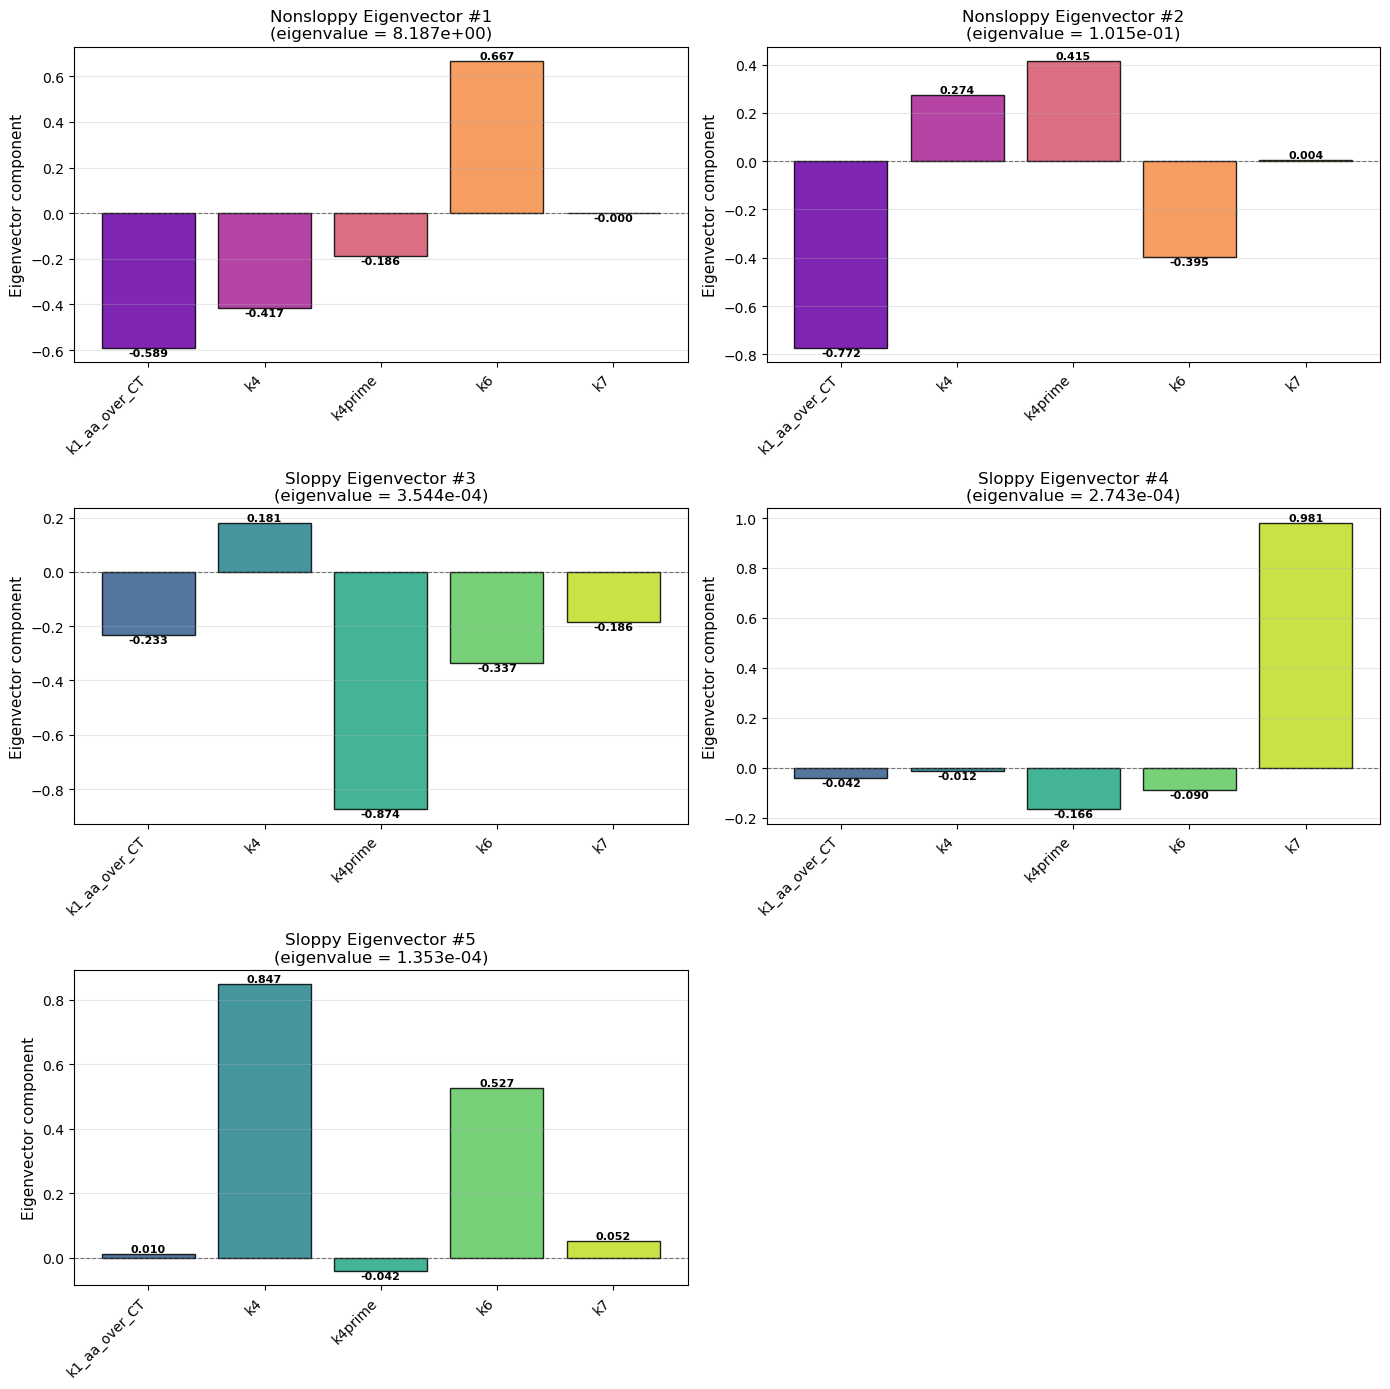

In [189]:
# === Analysis of sloppy eigenvectors: all with eigenvalues below threshold ===
# This helps interpret WHICH parameters are most involved in the sloppy modes


# Find all eigenvectors with eigenvalues below threshold
sloppy_indices = np.where(eigvals < sloppy_threshold)[0]
n_sloppy = len(sloppy_indices)

# Find all eigenvectors with eigenvalues at or above threshold
nonsloppy_indices = np.where(eigvals >= sloppy_threshold)[0]
n_nonsloppy = len(nonsloppy_indices)

# Build a single 3x2 figure: nonsloppy modes first, then sloppy modes below
n_show_nonsloppy = min(2, n_nonsloppy)
n_show_sloppy = min(4, n_sloppy)
ordered_indices = list(nonsloppy_indices[:n_show_nonsloppy]) + list(sloppy_indices[:n_show_sloppy])
ordered_labels = (["nonsloppy"] * n_show_nonsloppy) + (["sloppy"] * n_show_sloppy)

if len(ordered_indices) == 0:
    print(f"No eigenvalues found to plot with threshold {sloppy_threshold:.1e}")
else:
    print(f"Found {n_sloppy} sloppy eigenvector(s) with eigenvalues < {sloppy_threshold:.1e}")
    print(f"Plotting {n_show_nonsloppy} nonsloppy and {n_show_sloppy} sloppy eigenvector(s) in one 3x2 grid")

    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()
    x_pos = np.arange(P)

    for plot_idx, (eig_idx, mode_label) in enumerate(zip(ordered_indices, ordered_labels)):
        ax = axes[plot_idx]
        v = eigvecs[:, eig_idx]
        lam = eigvals[eig_idx]

        if mode_label == "nonsloppy":
            colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, P))
            title_prefix = "Nonsloppy"
        else:
            colors_bar = plt.cm.viridis(np.linspace(0.3, 0.9, P))
            title_prefix = "Sloppy"

        bars = ax.bar(x_pos, v, color=colors_bar, alpha=0.85, edgecolor='black', linewidth=1.0)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(param_names, rotation=45, ha='right')
        ax.set_ylabel('Eigenvector component', fontsize=11)
        ax.set_title(f'{title_prefix} Eigenvector #{eig_idx+1}\n(eigenvalue = {lam:.3e})', fontsize=12)
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, v):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:.3f}',
                    ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=8, weight='bold')

    for idx in range(len(ordered_indices), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()


# Apply step along sloppy eigenvector v
dlogh = step_size * v

In [190]:
# ----------------------------
# Iterative sloppy-stepping block
# ----------------------------
import copy
from scipy.integrate import solve_ivp
from numpy.linalg import eigh, svd

# helper: compute H for a parameter dict
def compute_H_for_params(p_local):
    P_local = len(param_names)
    def augmented_rhs_local(t, z):
        x = z[:6]
        S = z[6:].reshape((6, P_local), order='F')
        xdot    = f_rhs(t, x, p_local)
        A       = jacobian_fx(x, p_local)
        df_dh   = df_dparam(x, p_local)
        df_dlogh = np.zeros_like(df_dh)
        for j, name in enumerate(param_names):
            df_dlogh[:, j] = p_local[name] * df_dh[:, j]
        Sdot = A.dot(S) + df_dlogh
        return np.concatenate([xdot, Sdot.ravel(order='F')])
    z0_local = np.concatenate([y0, np.zeros((6, P_local)).ravel(order='F')])
    sol = solve_ivp(augmented_rhs_local, (t_span[0], t_span[1]), z0_local,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Augmented integration failed: " + sol.message)
    m_local    = sol.t.size
    S_flat_loc = sol.y[6:, :]
    S_time_loc = np.zeros((6, P_local, m_local))
    for i in range(m_local):
        S_time_loc[:, :, i] = S_flat_loc[:, i].reshape((6, P_local), order='F')
    Tc      = t_span[1] - t_span[0]
    W_local = np.diag(np.ones(6) / (6.0 * Tc))
    tt       = sol.t;  dt_loc = np.diff(tt)
    q_local  = np.zeros_like(tt)
    q_local[0]    = dt_loc[0] / 2.0;  q_local[-1] = dt_loc[-1] / 2.0
    q_local[1:-1] = 0.5 * (dt_loc[:-1] + dt_loc[1:])
    H_local = np.zeros((P_local, P_local))
    for i in range(m_local):
        J_i = S_time_loc[:, :, i]
        H_local += q_local[i] * J_i.T.dot(W_local).dot(J_i)
    ev, evec = eigh(H_local)
    ev = ev[::-1];  evec = evec[:, ::-1]
    return dict(H=H_local, eigvals=ev, eigvecs=evec,
                J_time=S_time_loc, t=sol.t, q=q_local, sol=sol)

# baseline
t_base, X_base = simulate_at_params(p, t_eval)
YT_base, M_base = compute_obs(X_base)

# trapezoid weights for scoring drift from baseline
_dt_q = np.diff(t_eval)
q_score = np.zeros_like(t_eval)
q_score[0]    = _dt_q[0] / 2.0;  q_score[-1] = _dt_q[-1] / 2.0
q_score[1:-1] = 0.5 * (_dt_q[:-1] + _dt_q[1:])

# history storage
param_history    = [copy.deepcopy(dict(p))]
logparam_history = [np.log([p[name] for name in param_names])]
eig_history      = []
vec_history      = []
score_history    = []
obs_history      = [(YT_base.copy(), M_base.copy())]

p_current = dict(p)
v_prev    = None   # for sign-alignment across steps

print("\nStarting iterative sloppy-stepping (n_steps = {})".format(n_steps))

for step in range(1, n_steps + 1):
    print("\n=== Step {:d} ===".format(step))

    res     = compute_H_for_params(p_current)
    eigvals = res['eigvals'];  eigvecs = res['eigvecs']
    eig_history.append(eigvals)
    vec_history.append(eigvecs)

    pos_idx = np.where(eigvals > tol_positive_eig)[0]
    if pos_idx.size == 0:
        print("No positive eigenvalues found at step", step, "— stopping.")
        break

    if MULT:
        # randomly select from all sloppy vectors weighted by -log10(lambda)
        epsilon    = 1e-30
        clipped    = np.maximum(eigvals[pos_idx], epsilon)
        log_w      = -np.log10(clipped)
        log_w      = np.maximum(log_w, 0)
        if not np.isfinite(log_w).all() or log_w.sum() <= 0:
            probs = np.ones(len(pos_idx)) / len(pos_idx)
        else:
            probs = log_w / log_w.sum()
        sloppy_idx = np.random.choice(pos_idx, p=probs)
        lam = eigvals[sloppy_idx]
        v   = eigvecs[:, sloppy_idx].copy()
        print(f"Chosen idx={sloppy_idx}, lambda={lam:.3e} (random log-weighted from {len(pos_idx)} modes)")
    else:
        # always use the most sloppy (smallest positive eigenvalue)
        sloppy_idx = pos_idx[-1]
        lam = eigvals[sloppy_idx]
        v   = eigvecs[:, sloppy_idx].copy()
        print(f"Chosen idx={sloppy_idx}, lambda={lam:.3e} (most sloppy)")

    # sign-align with previous direction so walk does not randomly reverse
    if v_prev is not None and np.dot(v, v_prev) < 0:
        v = -v
    v_prev = v.copy()

    # step always in the + direction
    dlogh = step_size * v
    if NOISE > 0:
        noise_vector = np.random.normal(0, np.sqrt(NOISE), size=P)
        dlogh = dlogh + noise_vector
        print(f"  Added noise (variance={NOISE:.4g})")

    p_next = dict(p_current)
    for j, name in enumerate(param_names):
        p_next[name] = p_current[name] * np.exp(dlogh[j])

    _, X_next     = simulate_at_params(p_next, t_eval)
    YT_next, M_next = compute_obs(X_next)

    # track observable drift from baseline
    score_drift = (float(q_score @ (YT_next - YT_base)**2) +
                   float(q_score @ (M_next  - M_base)**2))
    print(f"step_size={step_size:.4g}  drift_from_baseline={score_drift:.3e}")

    param_history.append(copy.deepcopy(p_next))
    logparam_history.append(np.log([p_next[name] for name in param_names]))
    score_history.append(score_drift)
    obs_history.append((YT_next.copy(), M_next.copy()))
    p_current = p_next

# arrays for plotting
n_recorded   = len(param_history)
logparam_mat = np.vstack(logparam_history)   # (n_recorded, P)

# ── Plot 1: YT/CT and M/CT overlaid across all steps ─────────────────────────
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i, (YT_i, _) in enumerate(obs_history):
    plt.plot(t_eval, YT_i, label='step 0' if i == 0 else f'step {i}',
             lw=1.3 if i == 0 else 1.0, alpha=0.9)
plt.xlabel('time');  plt.ylabel('YT / CT');  plt.title('YT / CT across steps');  plt.grid(True)
if n_recorded <= 20:  plt.legend()

plt.subplot(1, 2, 2)
for i, (_, M_i) in enumerate(obs_history):
    plt.plot(t_eval, M_i, label='step 0' if i == 0 else f'step {i}',
             lw=1.3 if i == 0 else 1.0, alpha=0.9)
plt.xlabel('time');  plt.ylabel('M / CT');  plt.title('M / CT across steps');  plt.grid(True)
if n_recorded <= 20:  plt.legend()
plt.tight_layout();  plt.show()

# ── Plot 2: successive differences ───────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i in range(1, n_recorded):
    Yprev, Mprev = obs_history[i - 1]
    Ycurr, Mcurr = obs_history[i]
    plt.plot(t_eval, Ycurr - Yprev, label=f'{i-1}→{i}')
plt.xlabel('time');  plt.ylabel('Δ YT / CT');  plt.title('Successive YT differences');  plt.grid(True)
if n_recorded <= 20:  plt.legend()

plt.subplot(1, 2, 2)
for i in range(1, n_recorded):
    Yprev, Mprev = obs_history[i - 1]
    Ycurr, Mcurr = obs_history[i]
    plt.plot(t_eval, Mcurr - Mprev, label=f'{i-1}→{i}')
plt.xlabel('time');  plt.ylabel('Δ M / CT');  plt.title('Successive M differences');  plt.grid(True)
if n_recorded <= 20:  plt.legend()
plt.tight_layout();  plt.show()


Starting iterative sloppy-stepping (n_steps = 100)

=== Step 1 ===
Chosen idx=4, lambda=1.354e-04 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=5.580e-01

=== Step 2 ===
Chosen idx=4, lambda=4.904e-05 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=2.126e+00

=== Step 3 ===
Chosen idx=4, lambda=1.535e-05 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=3.312e+00

=== Step 4 ===
Chosen idx=4, lambda=2.176e-05 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=5.365e+00

=== Step 5 ===
Chosen idx=4, lambda=2.634e-07 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=3.250e+00

=== Step 6 ===
Chosen idx=4, lambda=2.486e-05 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=2.118e+00

=== Step 7 ===
Chosen idx=4, lambda=2.210e-06 (most sloppy)
  Added noise (variance=0.01)
step_size=1  drift_from_baseline=2.216e+00

=== Step 

RuntimeError: Augmented integration failed: Required step size is less than spacing between numbers.

In [ ]:
# ── Eigenvalue evolution  +  eigenvector component evolution ──────────────────
# Requires: eig_history, vec_history from the walk cell.
# Top:    log10(eigenvalue) per sloppy mode across walk steps.
# Bottom: |eigenvector component| vs parameter at 10 sampled steps (blue→red).

if len(eig_history) < 2:
    print("Not enough steps recorded.")
else:
    n_rec = len(eig_history)

    # ── Track each initial sloppy mode across steps by eigenvector alignment ──
    sloppy_idx_init = np.where(eig_history[0] < sloppy_threshold)[0]
    n_modes         = len(sloppy_idx_init)

    if n_modes == 0:
        print("No sloppy modes in eig_history[0].")
    else:
        tracked_eigvals = np.zeros((n_modes, n_rec))
        tracked_vecs    = np.zeros((n_modes, P, n_rec))

        for mi, init_idx in enumerate(sloppy_idx_init):
            v_ref = vec_history[0][:, init_idx].copy()
            for s in range(n_rec):
                dots = np.abs(vec_history[s].T @ v_ref)
                best = int(np.argmax(dots))
                v_s  = vec_history[s][:, best].copy()
                if np.dot(v_s, v_ref) < 0:
                    v_s = -v_s
                v_ref                  = v_s.copy()
                tracked_eigvals[mi, s] = eig_history[s][best]
                tracked_vecs[mi, :, s] = v_s

        clrs      = plt.cm.tab10(np.linspace(0, 1, n_modes))
        steps_arr = np.arange(n_rec)

        mode_labels = []
        for mi, init_idx in enumerate(sloppy_idx_init):
            dom = param_names[int(np.argmax(np.abs(tracked_vecs[mi, :, 0])))]
            mode_labels.append(f'{dom}  (λ₀={eig_history[0][init_idx]:.2e})')

        # ── Plot 1: eigenvalue evolution (full log range) ─────────────────────
        plt.figure(figsize=(8, 4))
        for mi in range(n_modes):
            plt.plot(steps_arr,
                     np.log10(np.maximum(tracked_eigvals[mi], 1e-300)),
                     'o-', color=clrs[mi], label=mode_labels[mi],
                     linewidth=2, markersize=4, alpha=0.85)
        plt.axhline(np.log10(sloppy_threshold), color='red', linestyle='--',
                    linewidth=2, alpha=0.7, label=f'threshold ({sloppy_threshold:.0e})')
        plt.xlabel('Step number')
        plt.ylabel('log10(eigenvalue)')
        plt.title('Sloppy mode eigenvalue evolution across walk steps')
        plt.legend(loc='best', fontsize=9)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # ── Plot 2: eigenvector component evolution  2×2 ─────────────────────
        n_show   = min(4, n_modes)
        n_sample = 10
        ncols    = min(n_show, 2)
        nrows    = (n_show + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(7*ncols, 4.5*nrows), squeeze=False)
        x_pos = np.arange(P)

        for mi in range(n_show):
            sample_idx = np.unique(
                np.round(np.linspace(0, n_rec - 1, min(n_sample, n_rec))).astype(int))
            ax = axes[mi // ncols, mi % ncols]

            for i, si in enumerate(sample_idx):
                v_abs = np.abs(tracked_vecs[mi, :, si])
                color = plt.cm.coolwarm(i / max(1, len(sample_idx) - 1))
                ls    = '-' if i % 2 == 0 else '--'
                label = (f'step {si}'
                         if i in [0, len(sample_idx) // 2, len(sample_idx) - 1]
                         else None)
                ax.plot(x_pos, v_abs, marker='o', linestyle=ls, color=color,
                        label=label, linewidth=2.2, markersize=7, alpha=0.85,
                        markeredgecolor='black', markeredgewidth=0.4)

            ax.set_xticks(x_pos)
            ax.set_xticklabels(param_names, rotation=45, ha='right', fontsize=9)
            ax.set_ylabel('|Eigenvector component|')
            ax.set_xlabel('Parameter')
            ax.set_title(mode_labels[mi], fontsize=10)
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)

        for k in range(n_show, nrows * ncols):
            axes[k // ncols, k % ncols].set_visible(False)

        plt.suptitle('Eigenvector component evolution across walk steps', fontsize=13)
        plt.tight_layout()
        plt.show()

In [ ]:
# ----------------------------
# Trajectory visualization helpers
# Requires: numpy, matplotlib, mpl_toolkits.mplot3d, scipy (svd)
# Paste under your existing script (after param_history is available)
# ----------------------------
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm
from matplotlib.animation import FuncAnimation
from numpy.linalg import svd

def build_logparam_matrix(param_history, param_names):
    """Return (n_steps x P) matrix of log-parameters."""
    P = len(param_names)
    n = len(param_history)
    L = np.zeros((n, P))
    for i, pd in enumerate(param_history):
        use_log = True
        if use_log:
            L[i, :] = np.log([pd[name] for name in param_names])
        else:
            L[i, :] = [pd[name] for name in param_names]
    return L

# Find the top 3 parameters with largest absolute change
keys = list(param_history[0].keys())
# Find the top 3 parameters with largest change IN LOG-SPACE
# IMPORTANT: Only consider parameters that are being analyzed (in param_names)
log_v1 = np.array([np.log(param_history[0][name]) for name in param_names])
log_v2 = np.array([np.log(param_history[-1][name]) for name in param_names])
log_diff = np.abs(log_v2 - log_v1)
top3_idx = np.argsort(log_diff)[-3:][::-1]
top3_names = [param_names[i] for i in top3_idx]

print("Top 3 parameters for 3D visualization (by log-change):", top3_names)
print("Log-differences:")
for i in top3_idx:
    print(f"  {param_names[i]}: Δlog = {log_diff[i]:.4f} (factor of {np.exp(log_diff[i]):.2f})")

# Extract coords: the log-values of top 3 parameters across all steps
coords = np.zeros((len(param_history), 3))
for i, p_dict in enumerate(param_history):
    coords[i, :] = [np.log(p_dict[name]) for name in top3_names]


Top 3 parameters for 3D visualization (by log-change): ['k3_CT', 'k6', 'k4']
Log-differences:
  k3_CT: Δlog = 6.0910 (factor of 441.88)
  k6: Δlog = 0.5871 (factor of 1.80)
  k4: Δlog = 0.5569 (factor of 1.75)


/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_90632/3990202320.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_steps)


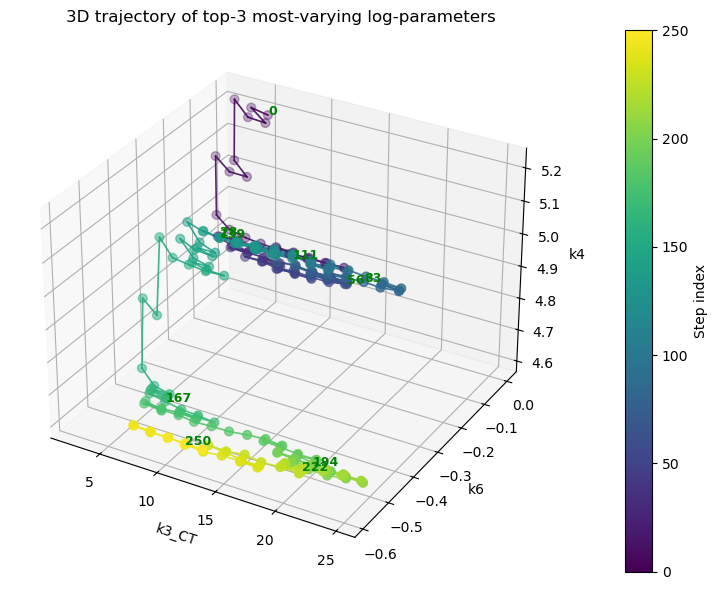

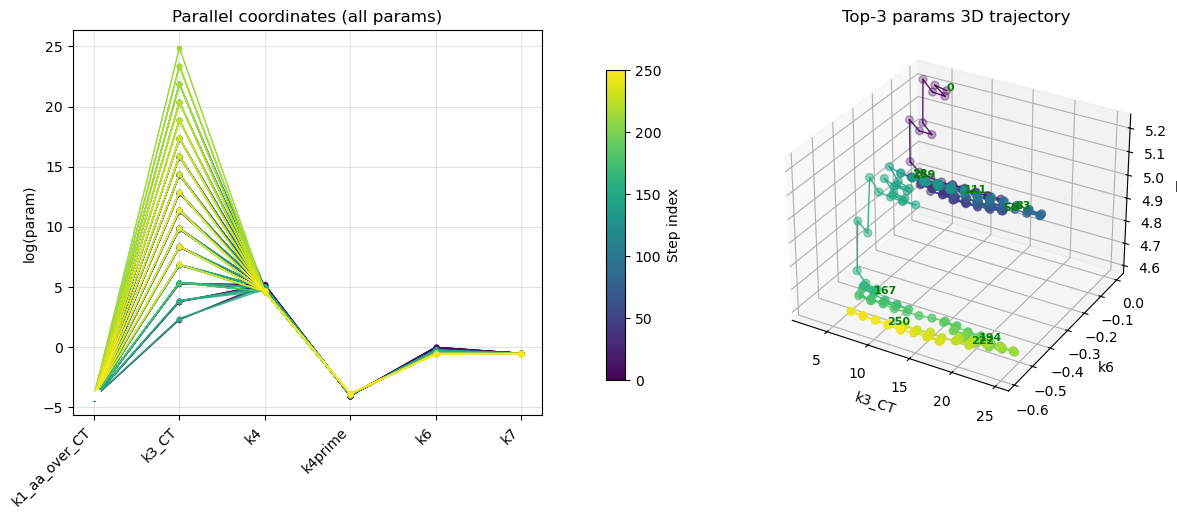

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as colors

# --- assume these already exist:
# logparam_mat  : shape (n_steps, n_params)
# param_names   : list of parameter names
# coords        : shape (n_steps, 3)
# top3_names    : list of 3 names

n_steps = logparam_mat.shape[0]
n_pts = coords.shape[0]

# choose about 10 labels (or fewer if n_steps < 10)
n_labels = min(10, max(1, n_steps))
label_indices = np.unique(np.round(np.linspace(0, n_steps - 1, n_labels)).astype(int))

# colormap & normalization
cmap = cm.get_cmap('viridis', n_steps)
norm = colors.Normalize(vmin=0, vmax=n_steps - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# ----------------------------
# Single 3D trajectory plot (no arrows)
# ----------------------------
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# draw colored line segments
for i in range(n_pts - 1):
    c = cmap(norm(i))
    ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2], '-', color=c, alpha=0.9, linewidth=1.2)

# scatter points with gradient color
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=np.arange(n_pts), cmap=cmap, norm=norm, s=40)

# white labels on selected steps
for k in label_indices:
    ax.text(coords[k, 0], coords[k, 1], coords[k, 2], f'{k}', fontsize=9, color='green', weight='bold')

ax.set_xlabel(top3_names[0])
ax.set_ylabel(top3_names[1])
ax.set_zlabel(top3_names[2])
ax.set_title('3D trajectory of top-3 most-varying log-parameters')

# colorbar for step index
cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.08)
cbar.set_label('Step index')

plt.tight_layout()
plt.show()

# ----------------------------
# Combined Parallel Coordinates + 3D Trajectory (no arrows)
# ----------------------------
fig = plt.figure(figsize=(13, 5))

# left: parallel coordinates
ax1 = fig.add_subplot(1, 2, 1)
xs = np.arange(len(param_names))
for i in range(n_steps):
    ax1.plot(xs, logparam_mat[i, :], '-o', color=cmap(norm(i)), alpha=0.9, markersize=3, linewidth=0.9)

# annotate only selected steps on the parallel coordinates
for k in label_indices:
    y = logparam_mat[k, 0]
    ax1.text(xs[0] - 0.08, y, f'{k}', fontsize=8, verticalalignment='center', color='white', weight='bold')

ax1.set_xticks(xs)
ax1.set_xticklabels(param_names, rotation=45, ha='right')
ax1.set_ylabel('log(param)')
ax1.set_title('Parallel coordinates (all params)')
ax1.grid(True, alpha=0.35)

# right: 3D trajectory
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for i in range(n_pts - 1):
    ax2.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2], '-', color=cmap(norm(i)), alpha=0.9, linewidth=1.0)

ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=np.arange(n_pts), cmap=cmap, norm=norm, s=32)

# white numeric labels
for k in label_indices:
    ax2.text(coords[k, 0], coords[k, 1], coords[k, 2], f'{k}', fontsize=8, color='green', weight='bold')

ax2.set_xlabel(top3_names[0])
ax2.set_ylabel(top3_names[1])
ax2.set_zlabel(top3_names[2])
ax2.set_title('Top-3 params 3D trajectory')

# shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.47, 0.18, 0.015, 0.62])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Step index')

fig.subplots_adjust(left=0.06, right=0.92, wspace=0.38)
plt.show()


In [ ]:
# two-line snippet
vals = [np.log(p['k3_CT']) for p in param_history]  # or just p['k3_CT'] for linear space
print("k3_CT (log) across steps:", np.round(vals, 6))

vals = [np.log(p['k8_minusP']) for p in param_history]  # or just p['k8_minusP'] for linear space
print("k8_minusP (log) across steps:", np.round(vals, 6))

vals = [np.log(p['k9']) for p in param_history]  # or just p['k9'] for linear space
print("k9 (log) across steps:", np.round(vals, 6))


keys = list(param_history[0].keys())
v1 = np.array([param_history[0][k] for k in keys])
v2 = np.array([param_history[n_steps-1][k] for k in keys])

# compute absolute differences
diff = np.abs(v2 - v1)

# find indices of top 3 changes
top3_idx = np.argsort(diff)[-3:][::-1]

print("Top 3 coordinates with largest change:\n")
for i in top3_idx:
    print(f"{keys[i]}:")
    print(f"  Step 0: {v1[i]:.6g}")
    print(f"  Step 1: {v2[i]:.6g}")
    print(f"  Δ (abs): {diff[i]:.6g}\n")


k3_CT (log) across steps: [ 5.298317  3.799069  5.301991  3.803125  2.304628  3.801021  5.298314
  3.800755  2.299213  3.796911  5.290865  6.794541  8.29436   9.793876
 11.290655  9.790415 11.294259 12.799504 11.297021 12.802029 14.305214
 15.808586 14.305538 12.806885 11.304209  9.806782  8.311136  6.816009
  5.318301  6.819623  5.313463  6.814843  8.3179    6.816389  8.31599
  6.814526  8.313264  9.818368 11.316837  9.821033 11.318635  9.818277
 11.319664  9.815927  8.31617   9.820958 11.329022 12.831236 11.330458
 12.833785 14.336379 12.83915  11.339257 12.838635 14.342611 15.838609
 17.340238 15.837421 14.33469  15.835927 17.336661 15.837244 14.340078
 15.850038 17.349995 15.849871 14.348002 12.84345  14.343207 15.844831
 17.346996 15.846678 14.343863 15.848632 14.351039 12.853363 11.350927
 12.856309 14.359644 15.859219 17.362037 15.864769 17.365806 18.868077
 20.366582 21.874141 20.377189 21.878166 20.377337 21.875033 20.37638
 18.877511 17.376685 15.876346 17.377937 15.875047 14

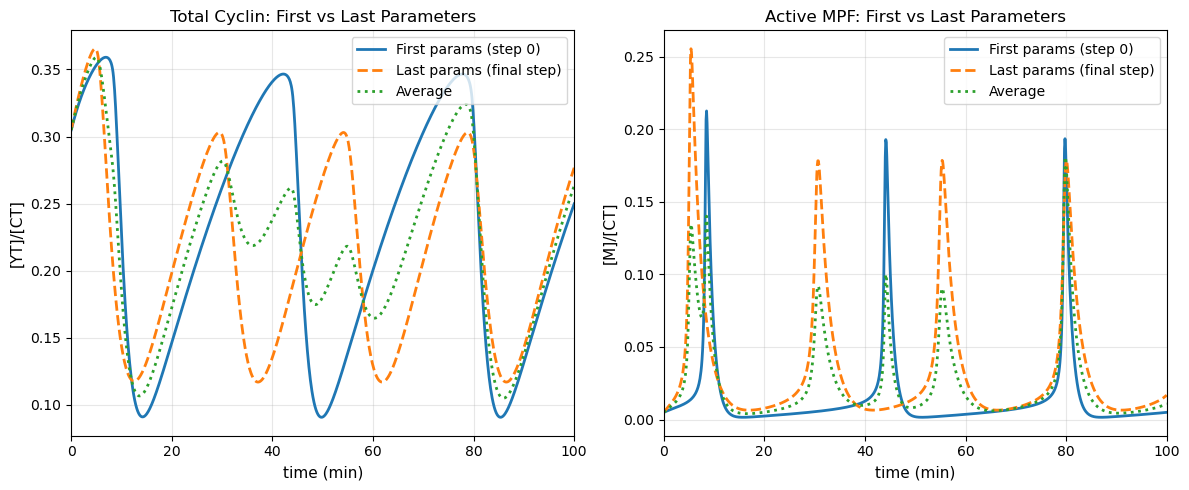


First parameter set (step 0):
  k1_aa_over_CT: 0.015
  k3_CT: 200
  k4: 180
  k4prime: 0.018
  k6: 1
  k7: 0.6

Last parameter set (step 250):
  k1_aa_over_CT: 0.0185108
  k3_CT: 88376.9
  k4: 103.133
  k4prime: 0.0213521
  k6: 0.55592
  k7: 0.583805


In [ ]:
# === Comparison plot: First vs Last parameter set (time 0-100) ===
# Get first and last parameter sets from history
p_first = param_history[0]
p_last = param_history[-1]

# Initial conditions
y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
t_span = (0, 100)
t_eval = np.linspace(0, 100, 1000)

# Simulate with first parameter set
sol_first = solve_ivp(lambda t, x: f_rhs(t, x, p_first), t_span, y0, 
                       t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-8)

# Simulate with last parameter set
sol_last = solve_ivp(lambda t, x: f_rhs(t, x, p_last), t_span, y0,
                      t_eval=t_eval, method='BDF', rtol=1e-6, atol=1e-8)

# Extract observables for first params
t_first = sol_first.t
y_first = sol_first.y
M_first = y_first[3]
Y_first, YP_first, pM_first = y_first[4], y_first[5], y_first[2]
YT_first = Y_first + YP_first + pM_first + M_first
M_rel_first = M_first / CT
YT_rel_first = YT_first / CT

# Extract observables for last params
t_last = sol_last.t
y_last = sol_last.y
M_last = y_last[3]
Y_last, YP_last, pM_last = y_last[4], y_last[5], y_last[2]
YT_last = Y_last + YP_last + pM_last + M_last
M_rel_last = M_last / CT
YT_rel_last = YT_last / CT

# Compute averages
YT_rel_avg = (YT_rel_first + YT_rel_last) / 2.0
M_rel_avg = (M_rel_first + M_rel_last) / 2.0

# Create comparison plots
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(t_first, YT_rel_first, lw=2, label='First params (step 0)', color='C0')
plt.plot(t_last, YT_rel_last, lw=2, label='Last params (final step)', color='C1', linestyle='--')
plt.plot(t_first, YT_rel_avg, lw=2, label='Average', color='C2', linestyle=':')
plt.xlim(0,100)
plt.xlabel('time (min)', fontsize=11)
plt.ylabel('[YT]/[CT]', fontsize=11)
plt.title('Total Cyclin: First vs Last Parameters', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(t_first, M_rel_first, lw=2, label='First params (step 0)', color='C0')
plt.plot(t_last, M_rel_last, lw=2, label='Last params (final step)', color='C1', linestyle='--')
plt.plot(t_first, M_rel_avg, lw=2, label='Average', color='C2', linestyle=':')
plt.xlim(0,100)
plt.xlabel('time (min)', fontsize=11)
plt.ylabel('[M]/[CT]', fontsize=11)
plt.title('Active MPF: First vs Last Parameters', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFirst parameter set (step 0):")
for name in param_names:
    print(f"  {name}: {p_first[name]:.6g}")
    
print(f"\nLast parameter set (step {len(param_history)-1}):")
for name in param_names:
    print(f"  {name}: {p_last[name]:.6g}")

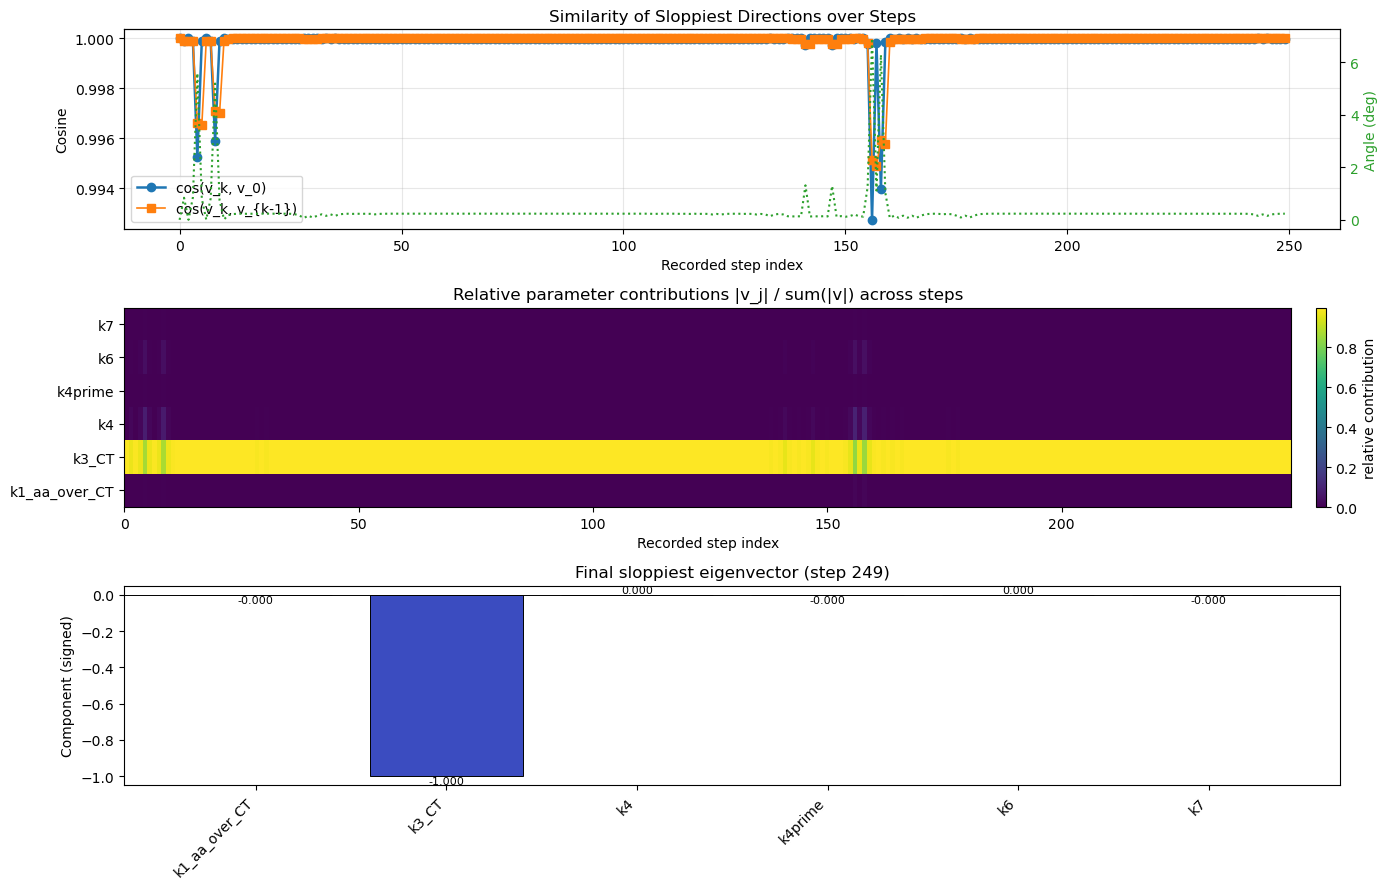

Recorded steps indices (in original history): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212

In [ ]:
# Visualize inner products / evolution of sloppiest eigenvectors across steps
import numpy as np
import matplotlib.pyplot as plt

# --- Collect sloppiest eigenvector per recorded step ---
sloppy_vecs = []
valid_steps = []
for k, (eigvals, eigvecs) in enumerate(zip(eig_history, vec_history)):
    # eigvals assumed descending; pick smallest positive eigenvalue index
    pos_idx = np.where(eigvals > tol_positive_eig)[0]
    if pos_idx.size == 0:
        # skip if no positive eigenvalue at this step
        continue
    sloppy_idx = pos_idx[-1]
    v = eigvecs[:, sloppy_idx].astype(float)
    # normalize to unit length to make inner products cosine-like
    nrm = np.linalg.norm(v)
    if nrm == 0:
        continue
    sloppy_vecs.append(v / nrm)
    valid_steps.append(k)

if len(sloppy_vecs) == 0:
    raise RuntimeError("No sloppiest eigenvectors found in recorded history (check eig_history / tol_positive_eig).")

sloppy_vecs = np.stack(sloppy_vecs, axis=0)  # shape (n_steps_recorded, P)
n_steps_rec, P = sloppy_vecs.shape

# --- Align signs to the first vector to avoid arbitrary flips ---
v0 = sloppy_vecs[0].copy()
aligned_vecs = sloppy_vecs.copy()
for i in range(1, n_steps_rec):
    if np.dot(v0, aligned_vecs[i]) < 0:
        aligned_vecs[i] = -aligned_vecs[i]

# --- Compute cosine similarities and angles ---
# cosine with initial
cos_with_initial = aligned_vecs.dot(v0)
cos_with_initial = np.clip(cos_with_initial, -1.0, 1.0)
angle_with_initial = np.degrees(np.arccos(cos_with_initial))

# successive cosines (between step i-1 and i)
succ_cos = np.empty(n_steps_rec)
succ_cos[0] = 1.0
for i in range(1, n_steps_rec):
    succ_cos[i] = np.clip(np.dot(aligned_vecs[i-1], aligned_vecs[i]), -1.0, 1.0)
succ_angles = np.degrees(np.arccos(succ_cos))

# --- Parameter contributions over steps (abs components) ---
abs_components = np.abs(aligned_vecs)  # shape (n_steps_rec, P)
# normalize rows so each step's components sum to 1 (relative contribution)
row_sums = abs_components.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
rel_contrib = abs_components / row_sums

# --- Plots ---
plt.figure(figsize=(14, 9))

# 1) cosine with initial and successive cosine
ax1 = plt.subplot(3, 1, 1)
steps_plot = np.arange(n_steps_rec)
ax1.plot(steps_plot, cos_with_initial, '-o', label='cos(v_k, v_0)', linewidth=1.8)
ax1.plot(steps_plot, succ_cos, '-s', label='cos(v_k, v_{k-1})', linewidth=1.2)
ax1.set_ylabel('Cosine')
ax1.set_xlabel('Recorded step index')
ax1.set_title('Similarity of Sloppiest Directions over Steps')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')

# Secondary axis: angle with initial (degrees)
ax1b = ax1.twinx()
ax1b.plot(steps_plot, angle_with_initial, ':', color='C2', label='angle w.r.t v0 (deg)')
ax1b.set_ylabel('Angle (deg)', color='C2')
ax1b.tick_params(axis='y', labelcolor='C2')

# 2) heatmap of absolute components (params x steps)
ax2 = plt.subplot(3, 1, 2)
im = ax2.imshow(rel_contrib.T, aspect='auto', origin='lower', cmap='viridis',
                extent=[0, n_steps_rec-1, 0, P])
ax2.set_yticks(np.arange(P) + 0.5)
ax2.set_yticklabels(param_names)
ax2.set_xlabel('Recorded step index')
ax2.set_title('Relative parameter contributions |v_j| / sum(|v|) across steps')
plt.colorbar(im, ax=ax2, fraction=0.02, pad=0.02, label='relative contribution')

# 3) bar chart of final sloppiest eigenvector components (signed)
ax3 = plt.subplot(3, 1, 3)
last_vec = aligned_vecs[-1]
x = np.arange(P)
colors = plt.cm.coolwarm((last_vec - last_vec.min()) / (last_vec.max() - last_vec.min() + 1e-16))
bars = ax3.bar(x, last_vec, color=colors, edgecolor='black', linewidth=0.7)
ax3.axhline(0, color='k', linewidth=0.7)
ax3.set_xticks(x)
ax3.set_xticklabels(param_names, rotation=45, ha='right')
ax3.set_ylabel('Component (signed)')
ax3.set_title(f'Final sloppiest eigenvector (step {valid_steps[-1]})')

# add value labels for bars
for i, (bar, val) in enumerate(zip(bars, last_vec)):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()*0.5, h,
             f'{val:.3f}', ha='center',
             va='bottom' if h >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

# --- Optional prints for quick numeric check ---
print(f"Recorded steps indices (in original history): {valid_steps}")
print(f"Number of recorded sloppiest vectors: {n_steps_rec}")
print("cosine with initial (first/last):", cos_with_initial[0], cos_with_initial[-1])
print("successive cosine (first/last):", succ_cos[0], succ_cos[-1])

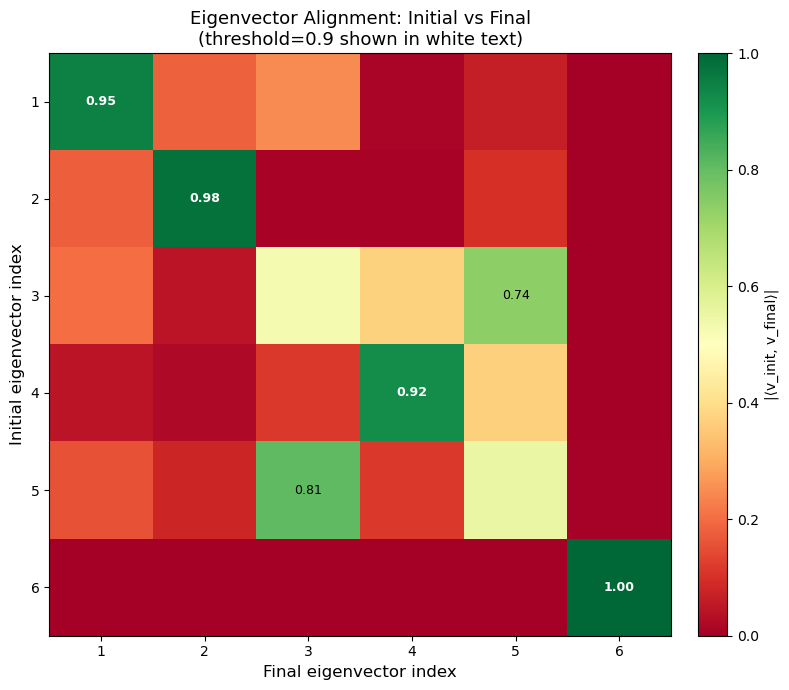


Found 4 sloppy modes at step 0 (λ < 1e-03)
Initial sloppy mode indices: [3 4 5 6]


/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_90632/1734113471.py:110: RuntimeWarning: invalid value encountered in log10
  ax1.plot(steps_array, np.log10(tracked_eigvals[mode_idx, :]),
/var/folders/dg/j3xfsm6j68s_0jk_l6mqmh_h0000gn/T/ipykernel_90632/1734113471.py:125: RuntimeWarning: invalid value encountered in log10
  ax2.plot(steps_array, np.log10(tracked_eigvals[mode_idx, :]),


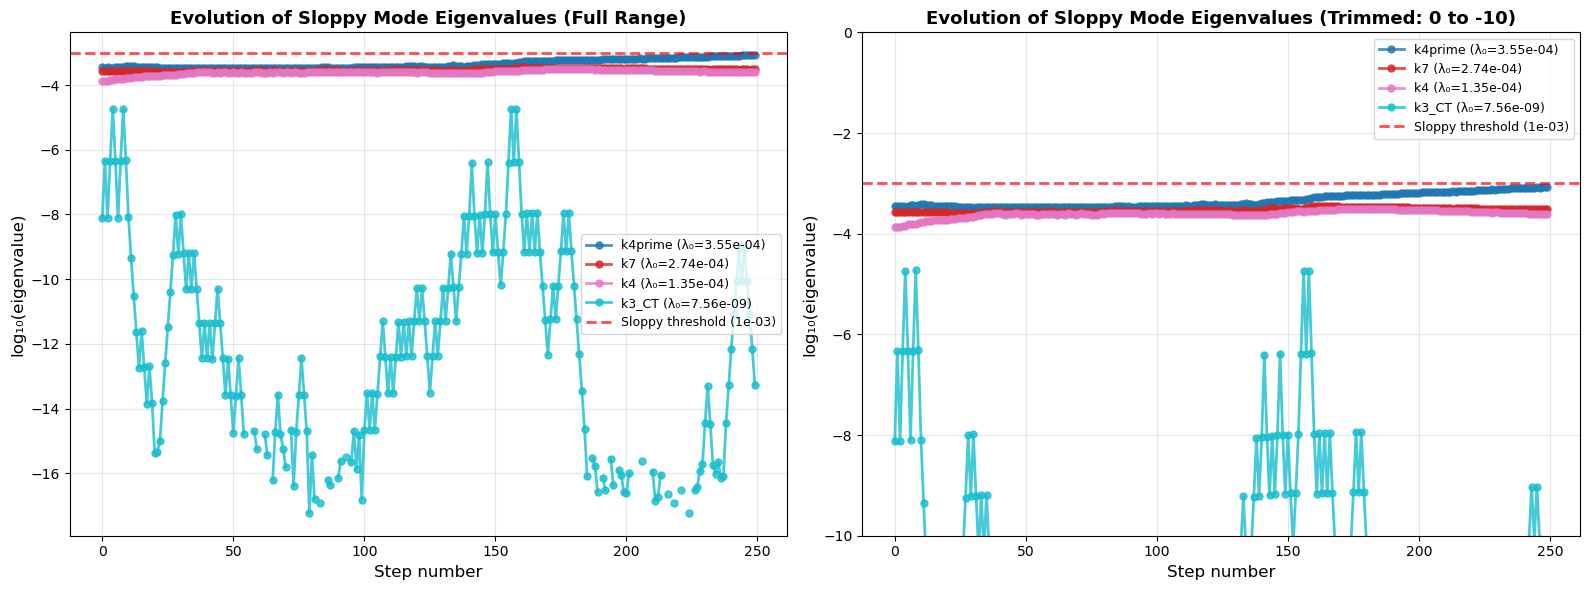


SLOPPY MODE TRACKING SUMMARY

Mode 3 (initial index):
  Initial eigenvalue:  3.548e-04
  Final eigenvalue:    8.405e-04
  Ratio (final/init):  2.369
  Final index tracked: 3
  Min alignment:       0.978
  Mean alignment:      0.999
  Stayed sloppy:       100.0% of steps

Mode 4 (initial index):
  Initial eigenvalue:  2.743e-04
  Final eigenvalue:    3.074e-04
  Ratio (final/init):  1.121
  Final index tracked: 4
  Min alignment:       0.838
  Mean alignment:      0.990
  Stayed sloppy:       100.0% of steps

Mode 5 (initial index):
  Initial eigenvalue:  1.354e-04
  Final eigenvalue:    2.477e-04
  Ratio (final/init):  1.830
  Final index tracked: 5
  Min alignment:       0.841
  Mean alignment:      0.991
  Stayed sloppy:       100.0% of steps

Mode 6 (initial index):
  Initial eigenvalue:  7.561e-09
  Final eigenvalue:    5.292e-14
  Ratio (final/init):  0.000
  Final index tracked: 6
  Min alignment:       0.995
  Mean alignment:      1.000
  Stayed sloppy:       100.0% of steps




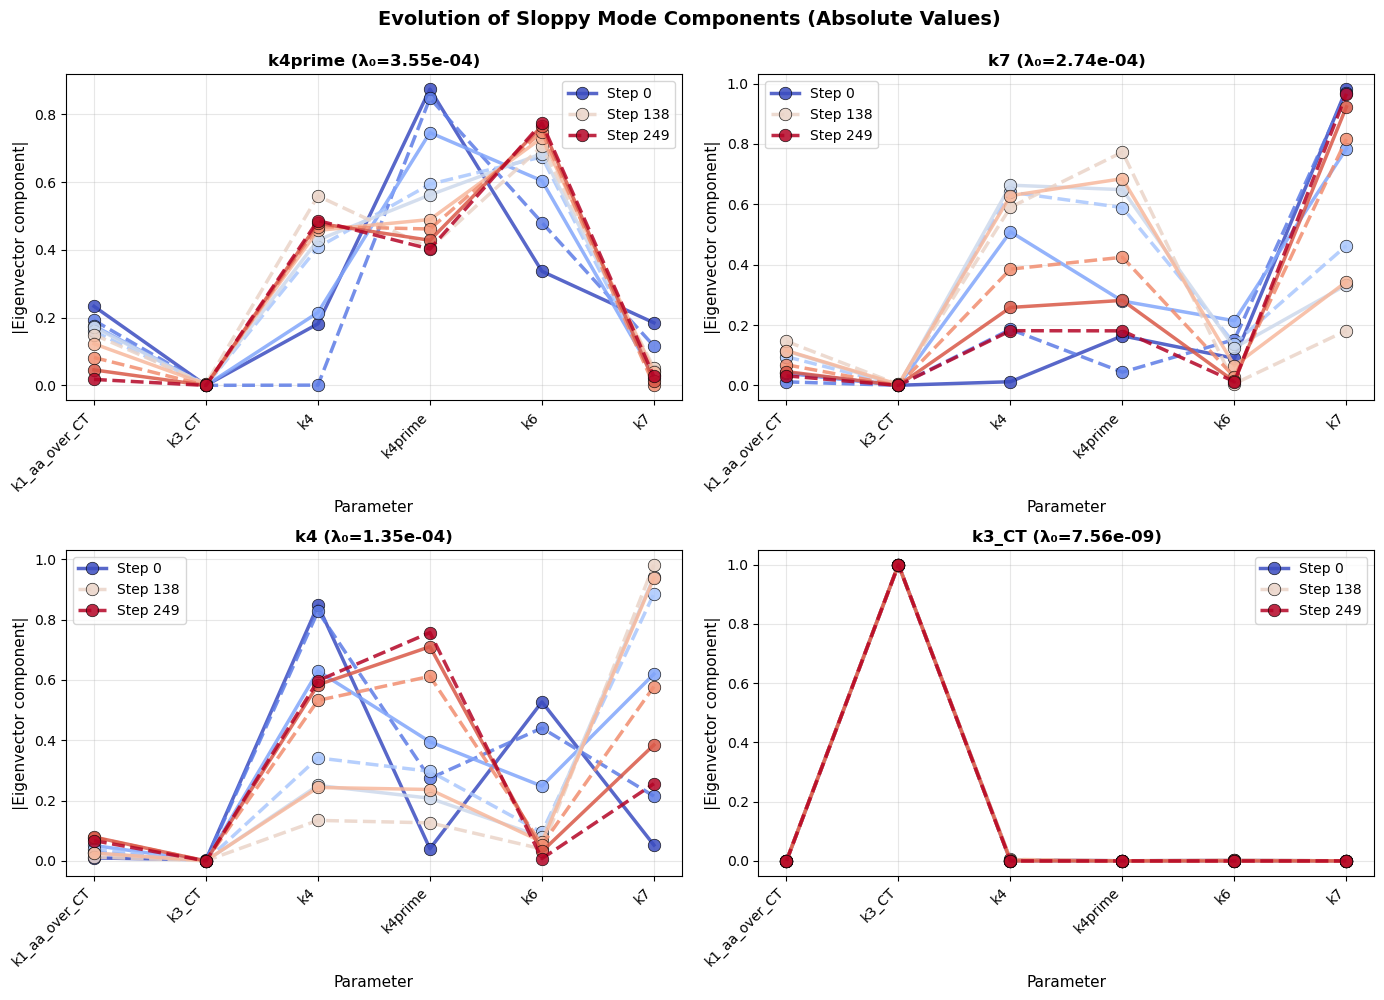

In [ ]:
# === Track sloppy eigenvalue evolution over time using eigenvector alignment ===
import numpy as np
import matplotlib.pyplot as plt

if len(eig_history) < 2:
    print("Not enough steps to track eigenvalue evolution")
else:
    P = len(param_names)
    n_steps = len(eig_history)
    alignment_threshold = 0.9  # threshold for considering eigenvectors as "same direction"
    
    # === Step 1: Show initial vs final alignment heatmap ===
    eigvals_init = eig_history[0]
    eigvecs_init = vec_history[0]
    eigvals_final = eig_history[-1]
    eigvecs_final = vec_history[-1]
    
    # Compute inner product matrix between initial and final eigenvectors
    inner_products = np.abs(eigvecs_init.T @ eigvecs_final)  # P x P matrix
    
    plt.figure(figsize=(8, 7))
    im = plt.imshow(inner_products, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    plt.xlabel('Final eigenvector index', fontsize=12)
    plt.ylabel('Initial eigenvector index', fontsize=12)
    plt.title(f'Eigenvector Alignment: Initial vs Final\n(threshold={alignment_threshold} shown in white text)', fontsize=13)
    plt.xticks(np.arange(P), np.arange(1, P+1))
    plt.yticks(np.arange(P), np.arange(1, P+1))
    plt.colorbar(im, fraction=0.046, pad=0.04, label='|⟨v_init, v_final⟩|')
    
    # Add text annotations for strong alignments
    for i in range(P):
        for j in range(P):
            if inner_products[i, j] > 0.7:
                color = 'white' if inner_products[i, j] > alignment_threshold else 'black'
                weight = 'bold' if inner_products[i, j] > alignment_threshold else 'normal'
                plt.text(j, i, f'{inner_products[i, j]:.2f}', 
                        ha='center', va='center', fontsize=9, color=color, weight=weight)
    
    plt.tight_layout()
    plt.show()
    
    # === Step 2: Track sloppy eigenvalues across all steps ===
    # Identify initial sloppy modes (below threshold)
    initial_sloppy_mask = eig_history[0] < sloppy_threshold
    n_sloppy_modes = np.sum(initial_sloppy_mask)
    initial_sloppy_indices = np.where(initial_sloppy_mask)[0]
    
    print(f"\nFound {n_sloppy_modes} sloppy modes at step 0 (λ < {sloppy_threshold:.0e})")
    print(f"Initial sloppy mode indices: {initial_sloppy_indices + 1}")
    
    if n_sloppy_modes == 0:
        print("No sloppy modes to track!")
    else:
        # Track each initial sloppy mode across all steps
        # tracked_eigvals[mode_idx, step] = eigenvalue of tracked mode at that step
        tracked_eigvals = np.zeros((n_sloppy_modes, n_steps))
        tracked_indices = np.zeros((n_sloppy_modes, n_steps), dtype=int)  # which index in each step
        alignment_scores = np.zeros((n_sloppy_modes, n_steps))  # how well aligned
        
        for mode_idx, init_eig_idx in enumerate(initial_sloppy_indices):
            # Start with the initial eigenvector for this mode
            current_vec = vec_history[0][:, init_eig_idx]
            tracked_eigvals[mode_idx, 0] = eig_history[0][init_eig_idx]
            tracked_indices[mode_idx, 0] = init_eig_idx
            alignment_scores[mode_idx, 0] = 1.0
            
            # Track through subsequent steps
            for step in range(1, n_steps):
                eigvecs_step = vec_history[step]
                eigvals_step = eig_history[step]
                
                # Compute inner products with all eigenvectors at this step
                inner_prods = np.abs(current_vec @ eigvecs_step)  # shape (P,)
                
                # Find best match
                best_match_idx = np.argmax(inner_prods)
                best_alignment = inner_prods[best_match_idx]
                
                # Store results
                tracked_eigvals[mode_idx, step] = eigvals_step[best_match_idx]
                tracked_indices[mode_idx, step] = best_match_idx
                alignment_scores[mode_idx, step] = best_alignment
                
                # Update current_vec for next step (with sign alignment)
                next_vec = eigvecs_step[:, best_match_idx]
                if np.dot(current_vec, next_vec) < 0:
                    next_vec = -next_vec
                current_vec = next_vec
        
        # === Step 3: Plot tracked sloppy eigenvalues over time ===
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        steps_array = np.arange(n_steps)
        colors_modes = plt.cm.tab10(np.linspace(0, 1, n_sloppy_modes))
        
        # Create labels based on dominant parameter component
        mode_labels = []
        for mode_idx in range(n_sloppy_modes):
            init_idx = initial_sloppy_indices[mode_idx]
            init_eigvec = vec_history[0][:, init_idx]
            # Find parameter with largest absolute component
            dominant_param_idx = np.argmax(np.abs(init_eigvec))
            dominant_param = param_names[dominant_param_idx]
            λ_init = eig_history[0][init_idx]
            mode_labels.append(f'{dominant_param} (λ₀={λ_init:.2e})')
        
        # Plot 1: Full log scale
        ax1 = axes[0]
        for mode_idx in range(n_sloppy_modes):
            ax1.plot(steps_array, np.log10(tracked_eigvals[mode_idx, :]), 
                    'o-', label=mode_labels[mode_idx], color=colors_modes[mode_idx], 
                    linewidth=2, markersize=5, alpha=0.8)
        
        ax1.axhline(np.log10(sloppy_threshold), color='red', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f'Sloppy threshold ({sloppy_threshold:.0e})')
        ax1.set_xlabel('Step number', fontsize=12)
        ax1.set_ylabel('log₁₀(eigenvalue)', fontsize=12)
        ax1.set_title('Evolution of Sloppy Mode Eigenvalues (Full Range)', fontsize=13, fontweight='bold')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Trimmed log scale (from -3 downward to more negative values)
        ax2 = axes[1]
        for mode_idx in range(n_sloppy_modes):
            ax2.plot(steps_array, np.log10(tracked_eigvals[mode_idx, :]), 
                    'o-', label=mode_labels[mode_idx], color=colors_modes[mode_idx], 
                    linewidth=2, markersize=5, alpha=0.8)
        
        ax2.axhline(np.log10(sloppy_threshold), color='red', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f'Sloppy threshold ({sloppy_threshold:.0e})')
        ax2.set_xlabel('Step number', fontsize=12)
        ax2.set_ylabel('log₁₀(eigenvalue)', fontsize=12)
        ax2.set_title('Evolution of Sloppy Mode Eigenvalues (Trimmed: 0 to -10)', fontsize=13, fontweight='bold')
        
        # Set y-limits: from 0 at top to -10 at bottom
        ax2.set_ylim([-10, 0])  # Top is 0, bottom is -10
        ax2.legend(loc='best', fontsize=9)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # === Step 4: Summary statistics ===
        print(f"\n{'='*70}")
        print("SLOPPY MODE TRACKING SUMMARY")
        print(f"{'='*70}")
        for mode_idx in range(n_sloppy_modes):
            init_idx = initial_sloppy_indices[mode_idx]
            final_idx = tracked_indices[mode_idx, -1]
            λ_init = tracked_eigvals[mode_idx, 0]
            λ_final = tracked_eigvals[mode_idx, -1]
            min_alignment = np.min(alignment_scores[mode_idx, :])
            mean_alignment = np.mean(alignment_scores[mode_idx, :])
            
            print(f"\nMode {init_idx+1} (initial index):")
            print(f"  Initial eigenvalue:  {λ_init:.3e}")
            print(f"  Final eigenvalue:    {λ_final:.3e}")
            print(f"  Ratio (final/init):  {λ_final/λ_init:.3f}")
            print(f"  Final index tracked: {final_idx+1}")
            print(f"  Min alignment:       {min_alignment:.3f}")
            print(f"  Mean alignment:      {mean_alignment:.3f}")
            
            # Check if mode stayed sloppy
            stayed_sloppy = tracked_eigvals[mode_idx, :] < sloppy_threshold
            percent_sloppy = 100 * np.sum(stayed_sloppy) / n_steps
            print(f"  Stayed sloppy:       {percent_sloppy:.1f}% of steps")
        
        print(f"\n{'='*70}")
        
        # === Step 5: Eigenvector component evolution over trajectory ===
        # Sample exactly 10 evenly spaced steps
        n_sample_steps = min(10, n_steps)
        sample_indices = np.linspace(0, n_steps-1, n_sample_steps, dtype=int)
        
        print(f"\nSampling {n_sample_steps} steps for component evolution:")
        print(f"Step indices: {sample_indices}")
        
        # Create 2x2 subplot grid
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        # Process each sloppy mode
        for mode_idx in range(min(4, n_sloppy_modes)):  # Max 4 modes in 2x2 grid
            init_idx = initial_sloppy_indices[mode_idx]
            dominant_param_idx = np.argmax(np.abs(vec_history[0][:, init_idx]))
            dominant_param = param_names[dominant_param_idx]
            
            ax = axes[mode_idx]
            
            # Plot ALL 10 sampled steps with distinct visualization
            for i, step_idx in enumerate(sample_indices):
                eig_idx_at_step = tracked_indices[mode_idx, step_idx]
                eigvec_at_step = vec_history[step_idx][:, eig_idx_at_step]
                
                # Align sign with initial vector for consistency
                if step_idx > 0:
                    prev_step = sample_indices[i-1]
                    prev_eig_idx = tracked_indices[mode_idx, prev_step]
                    prev_vec = vec_history[prev_step][:, prev_eig_idx]
                    if np.dot(prev_vec, eigvec_at_step) < 0:
                        eigvec_at_step = -eigvec_at_step
                
                # Use ABSOLUTE values
                eigvec_abs = np.abs(eigvec_at_step)
                
                # Create color gradient from blue (early) to red (late)
                color = plt.cm.coolwarm(i / max(1, n_sample_steps - 1))
                
                # Plot with larger markers and thicker lines
                # Vary line style slightly to make overlapping lines more visible
                x_pos = np.arange(P)
                linestyle = '-' if i % 2 == 0 else '--'
                
                if i in [0, n_sample_steps//2, n_sample_steps-1]:
                    label = f'Step {step_idx}'
                else:
                    label = None  # Don't add to legend
                
                ax.plot(x_pos, eigvec_abs, marker='o', linestyle=linestyle, color=color, 
                       label=label, linewidth=2.5, markersize=9, alpha=0.85, 
                       markeredgecolor='black', markeredgewidth=0.5)
            
            ax.set_xticks(np.arange(P))
            ax.set_xticklabels(param_names, rotation=45, ha='right')
            ax.set_ylabel('|Eigenvector component|', fontsize=11)
            ax.set_xlabel('Parameter', fontsize=11)
            ax.set_title(f'{dominant_param} (λ₀={eig_history[0][init_idx]:.2e})', 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best', fontsize=10, ncol=1)
        
        # Hide unused subplots if fewer than 4 sloppy modes
        for idx in range(n_sloppy_modes, 4):
            axes[idx].axis('off')
        
        plt.suptitle('Evolution of Sloppy Mode Components (Absolute Values)', 
                     fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()


In [ ]:
# ================================================================================
# EIGENVECTOR SELECTION SUMMARY TABLE (with composition change detection)
# ================================================================================
import numpy as np

print("="*80)
print("EIGENVECTOR SELECTION SUMMARY")
print("="*80)
print(f"{'Step':>4} | {'Index':>5} | {'Eigenvalue':>12} | Dominant Parameters")
print("-"*80)

# Reconstruct which eigenvector was chosen at each step
all_chosen_indices = []
all_chosen_eigvals = []
all_chosen_eigvecs = []  # Store eigenvectors for composition comparison
all_eigvals_full = []

composition_change_threshold = 0.3  # Threshold for detecting significant composition change

for step_idx in range(len(eig_history)):
    eigvals_step = eig_history[step_idx]
    eigvecs_step = vec_history[step_idx]
    
    # Store full eigenvalues for switch analysis
    all_eigvals_full.append(eigvals_step)
    
    # Find the chosen sloppy index (smallest positive eigenvalue)
    pos_idx = np.where(eigvals_step > tol_positive_eig)[0]
    if pos_idx.size == 0:
        print(f"{step_idx:>4} | {'N/A':>5} | {'No positive':>12} | No positive eigenvalues")
        all_chosen_indices.append(-1)
        all_chosen_eigvals.append(np.nan)
        all_chosen_eigvecs.append(None)
        continue
    
    chosen_idx = pos_idx[-1]
    chosen_eigval = eigvals_step[chosen_idx]
    chosen_eigvec = eigvecs_step[:, chosen_idx]
    
    all_chosen_indices.append(chosen_idx)
    all_chosen_eigvals.append(chosen_eigval)
    all_chosen_eigvecs.append(chosen_eigvec.copy())
    
    # Find top 3 dominant parameters by absolute component value
    abs_components = np.abs(chosen_eigvec)
    top3_param_indices = np.argsort(abs_components)[-3:][::-1]
    
    # Build dominant parameters string with signs
    dom_params = []
    for param_idx in top3_param_indices:
        param_name = param_names[param_idx]
        component_val = chosen_eigvec[param_idx]
        sign = '+' if component_val >= 0 else ''
        dom_params.append(f"{param_name}({sign}{component_val:.2f})")
    
    dom_params_str = ", ".join(dom_params)
    
    # Print row
    print(f"{step_idx:>4} | {chosen_idx+1:>5} | {chosen_eigval:>12.3e} | {dom_params_str}")
    
    # Check for composition change from previous step
    if step_idx > 0 and all_chosen_eigvecs[step_idx-1] is not None:
        prev_eigvec = all_chosen_eigvecs[step_idx-1]
        curr_eigvec = chosen_eigvec
        
        # Compute cosine similarity (alignment) - accounts for sign flips
        alignment = np.abs(np.dot(prev_eigvec, curr_eigvec))
        
        # Detect significant composition change
        if alignment < (1.0 - composition_change_threshold):
            prev_idx = all_chosen_indices[step_idx-1]
            curr_idx = all_chosen_indices[step_idx]
            
            # Find what changed in dominant parameters
            prev_abs = np.abs(prev_eigvec)
            curr_abs = np.abs(curr_eigvec)
            prev_dom = np.argmax(prev_abs)
            curr_dom = np.argmax(curr_abs)
            
            print(f"       ╰─> COMPOSITION CHANGE (alignment = {alignment:.3f})")
            print(f"           Index: {prev_idx+1} → {curr_idx+1}")
            print(f"           Dominant param shifted: {param_names[prev_dom]} → {param_names[curr_dom]}")
            print(f"           Previous eigenvalue: λ = {all_chosen_eigvals[step_idx-1]:.3e}")
            print(f"           Current eigenvalue:  λ = {chosen_eigval:.3e}")
            
            # Show component-wise changes for top parameters
            print(f"           Component changes (top params):")
            # Get union of top 3 params from both steps
            prev_top3 = np.argsort(prev_abs)[-3:][::-1]
            curr_top3 = np.argsort(curr_abs)[-3:][::-1]
            all_top_params = sorted(set(prev_top3) | set(curr_top3))
            
            for param_idx in all_top_params:
                prev_val = prev_eigvec[param_idx]
                curr_val = curr_eigvec[param_idx]
                change = curr_val - prev_val
                print(f"             {param_names[param_idx]:>15s}: {prev_val:+.3f} → {curr_val:+.3f} (Δ={change:+.3f})")

print("="*80)

# Summary statistics
print(f"\nSummary:")
print(f"  Total steps analyzed: {len(eig_history)}")
print(f"  Composition change threshold: {composition_change_threshold} (alignment < {1-composition_change_threshold:.2f})")

# Count unique indices used
unique_indices = set([idx for idx in all_chosen_indices if idx != -1])
print(f"  Unique eigenvector indices used: {sorted([i+1 for i in unique_indices])}")

print("="*80)

EIGENVECTOR SELECTION SUMMARY
Step | Index |   Eigenvalue | Dominant Parameters
--------------------------------------------------------------------------------
   0 |     6 |    7.561e-09 | k3_CT(-1.00), k4(+0.00), k6(+0.00)
   1 |     6 |    4.646e-07 | k3_CT(-1.00), k4(+0.02), k6(+0.01)
   2 |     6 |    7.521e-09 | k3_CT(-1.00), k4(+0.00), k6(+0.00)
   3 |     6 |    4.607e-07 | k3_CT(-1.00), k4(+0.02), k6(+0.01)
   4 |     6 |    1.838e-05 | k3_CT(-0.99), k4(+0.09), k6(+0.04)
   5 |     6 |    4.655e-07 | k3_CT(-1.00), k4(+0.02), k6(+0.01)
   6 |     6 |    7.835e-09 | k3_CT(-1.00), k4(+0.00), k6(+0.00)
   7 |     6 |    4.661e-07 | k3_CT(+1.00), k4(-0.02), k6(-0.01)
   8 |     6 |    1.859e-05 | k3_CT(-1.00), k4(+0.08), k6(+0.04)
   9 |     6 |    4.789e-07 | k3_CT(-1.00), k4(+0.02), k6(+0.01)
  10 |     6 |    8.125e-09 | k3_CT(-1.00), k4(+0.00), k6(+0.00)
  11 |     6 |    4.386e-10 | k3_CT(-1.00), k4(+0.00), k6(+0.00)
  12 |     6 |    2.976e-11 | k3_CT(-1.00), k4(+0.00), k6(+

In [ ]:
# ============================================================
# Multi-run sloppy stepping  —  N_RUNS independent trajectories
# Controlled by RANDOM_STARTING_POINT (Cell 0)
# Requires: all helpers from Cell 1 and Cell 3 already run
# ============================================================
import copy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

N_RUNS = 6

def _random_start(p_template):
    """Return a copy of p_template with each non-CT parameter randomly scaled."""
    multipliers = [1/8, 1/4, 1/2, 1, 2, 4, 8]
    out = dict(p_template)
    for name in out:
        if name != "CT":
            out[name] = out[name] * np.random.choice(multipliers)
    return out

def run_sloppy_steps(p_start):
    """Run n_steps of sloppy stepping from p_start.
    Returns (logparam_mat, param_history, obs_history, score_history,
             eig_history, vec_history).
    eig_history[i]/vec_history[i] = eigenvalues/vectors at step i.
    """
    t_eval_run = t_eval
    p_cur = dict(p_start)
    param_hist    = [copy.deepcopy(p_cur)]
    logparam_hist = [np.log([p_cur[name] for name in param_names])]
    obs_hist, score_hist, eig_hist, vec_hist = [], [], [], []

    _, X0b = simulate_at_params(p_cur, t_eval_run)
    YT0b, M0b = compute_obs(X0b)
    obs_hist.append((YT0b.copy(), M0b.copy()))

    for step in range(1, n_steps + 1):
        res = compute_H_for_params(p_cur)
        ev, evec = res['eigvals'], res['eigvecs']
        eig_hist.append(ev.copy())
        vec_hist.append(evec.copy())

        pos_idx = np.where(ev > tol_positive_eig)[0]
        if pos_idx.size == 0:
            break

        if MULT:
            eps = 1e-30
            clipped = np.maximum(ev[pos_idx], eps)
            lw = clipped
            lw = np.maximum(lw, 0)
            tot = lw.sum()
            probs = lw / tot if tot > 0 else np.ones(len(pos_idx)) / len(pos_idx)
            probs /= probs.sum()
            sloppy_idx = np.random.choice(pos_idx, p=probs)
        else:
            sloppy_idx = pos_idx[-1]

        v = evec[:, sloppy_idx]
        dlogh = step_size * v
        if NOISE > 0:
            dlogh = dlogh + np.random.normal(0, np.sqrt(NOISE), size=P)

        p_plus  = {name: p_cur[name] * np.exp(+dlogh[j]) for j, name in enumerate(param_names)}
        p_minus = {name: p_cur[name] * np.exp(-dlogh[j]) for j, name in enumerate(param_names)}
        for k in p_cur:
            if k not in param_names:
                p_plus[k] = p_cur[k]; p_minus[k] = p_cur[k]

        tt = t_eval_run
        dt_r = np.diff(tt)
        q_r = np.zeros_like(tt)
        q_r[0] = dt_r[0]/2; q_r[-1] = dt_r[-1]/2
        q_r[1:-1] = 0.5*(dt_r[:-1]+dt_r[1:])

        _, Xc = simulate_at_params(p_cur,   tt); YTc, Mc = compute_obs(Xc)
        _, Xp = simulate_at_params(p_plus,  tt); YTp, Mp = compute_obs(Xp)
        _, Xm = simulate_at_params(p_minus, tt); YTm, Mm = compute_obs(Xm)

        def isq(A, B): return np.sum(q_r * (A-B)**2)
        if isq(YTc,YTp)+isq(Mc,Mp) <= isq(YTc,YTm)+isq(Mc,Mm):
            p_next, YT_n, M_n, sc = p_plus,  YTp, Mp, isq(YTc,YTp)+isq(Mc,Mp)
        else:
            p_next, YT_n, M_n, sc = p_minus, YTm, Mm, isq(YTc,YTm)+isq(Mc,Mm)

        param_hist.append(copy.deepcopy(p_next))
        logparam_hist.append(np.log([p_next[name] for name in param_names]))
        obs_hist.append((YT_n.copy(), M_n.copy()))
        score_hist.append(sc)
        p_cur = p_next

    return np.vstack(logparam_hist), param_hist, obs_hist, score_hist, eig_hist, vec_hist


# ── Run N_RUNS times ──────────────────────────────────────────────────────
all_lpm       = []
all_eig_hists = []
all_vec_hists = []

for run in range(N_RUNS):
    print(f"Run {run+1}/{N_RUNS} ...", end=' ', flush=True)
    p_run = _random_start(p_canonical) if RANDOM_STARTING_POINT else dict(p_canonical)
    lpm, _, _, _, eh, vh = run_sloppy_steps(p_run)
    all_lpm.append(lpm)
    all_eig_hists.append(eh)
    all_vec_hists.append(vh)
    print(f"done  ({lpm.shape[0]-1} steps)")

xs_pc = np.arange(len(param_names))


# ── Figure 1: Log-parameter trajectories (parallel coordinates)  2×3 ─────
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 9))
for run, ax in enumerate(axes1.flatten()):
    lpm = all_lpm[run]
    n_s = lpm.shape[0]
    cmap_r = cm.get_cmap('viridis', max(n_s, 2))
    norm_r = mcolors.Normalize(vmin=0, vmax=max(n_s-1, 1))
    for i in range(n_s):
        ax.plot(xs_pc, lpm[i, :], '-o', color=cmap_r(norm_r(i)),
                alpha=0.75, markersize=3, linewidth=0.9)
    ax.set_xticks(xs_pc)
    ax.set_xticklabels(param_names, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('log(param)', fontsize=9)
    ax.set_title(f'Run {run+1}  ({n_s-1} steps)', fontsize=10)
    ax.grid(True, alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap=cmap_r, norm=norm_r)
    sm.set_array([])
    fig1.colorbar(sm, ax=ax, fraction=0.04, pad=0.02, label='step')
fig1.suptitle('Log-parameter trajectories (parallel coordinates)', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 2: 3D trajectory of top-3 most-varying log-params  2×3 ─────────
fig2 = plt.figure(figsize=(18, 12))
for run in range(N_RUNS):
    lpm = all_lpm[run]
    log_diff = np.abs(lpm[-1] - lpm[0])
    top3 = np.argsort(log_diff)[-3:][::-1]
    coords = lpm[:, top3]          # (n_steps+1, 3)
    n_s = lpm.shape[0]
    cmap_r = cm.get_cmap('viridis', max(n_s, 2))
    norm_r = mcolors.Normalize(vmin=0, vmax=max(n_s-1, 1))

    ax = fig2.add_subplot(2, 3, run+1, projection='3d')
    for i in range(n_s - 1):
        c = cmap_r(norm_r(i))
        ax.plot(coords[i:i+2, 0], coords[i:i+2, 1], coords[i:i+2, 2],
                '-', color=c, alpha=0.9, linewidth=1.2)
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
               c=np.arange(n_s), cmap=cmap_r, norm=norm_r, s=25)
    ax.set_xlabel(param_names[top3[0]], fontsize=7, labelpad=2)
    ax.set_ylabel(param_names[top3[1]], fontsize=7, labelpad=2)
    ax.set_zlabel(param_names[top3[2]], fontsize=7, labelpad=2)
    ax.set_title(f'Run {run+1}', fontsize=10)
    ax.tick_params(labelsize=7)

fig2.suptitle('3D trajectory — top-3 most-varying log-parameters', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 3: Eigenvalue spectrum evolution over trajectory  2×3 ──────────
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 9))
for run, ax in enumerate(axes3.flatten()):
    eh = all_eig_hists[run]          # list of eigvals arrays (one per step)
    if len(eh) == 0:
        ax.set_title(f'Run {run+1}: no data'); continue
    eig_mat = np.array(eh)           # shape (n_steps, P)
    for j in range(P):
        log_ev = np.log10(np.maximum(eig_mat[:, j], 1e-30))
        ax.plot(np.arange(len(eh)), log_ev, '-o',
                label=f'\u03bb{j+1}', markersize=3, linewidth=1.0)
    ax.axhline(np.log10(sloppy_threshold), color='red', linestyle='--',
               linewidth=1.2, alpha=0.7, label='sloppy threshold')
    ax.set_xlabel('Step', fontsize=9)
    ax.set_ylabel('log\u2081\u2080(eigenvalue)', fontsize=9)
    ax.set_title(f'Run {run+1}', fontsize=10)
    ax.grid(True, alpha=0.3)
    if run == 0:
        ax.legend(fontsize=8, loc='upper right')
fig3.suptitle('Eigenvalue spectrum evolution along trajectory', fontsize=13)
plt.tight_layout()
plt.show()


# ── Figure 4: Eigenvector inner-product matrices (start vs end)  2×3 ──────
fig4, axes4 = plt.subplots(2, 3, figsize=(15, 10))
for run, ax in enumerate(axes4.flatten()):
    vh = all_vec_hists[run]
    if len(vh) < 2:
        ax.set_title(f'Run {run+1}: too few steps'); continue
    V_start = vh[0]    # (P, P) columns = eigenvectors at first computed step
    V_end   = vh[-1]   # (P, P) columns = eigenvectors at last step
    IP = np.abs(V_start.T @ V_end)   # (P,P): |<v_start_i, v_end_j>|
    im = ax.imshow(IP, vmin=0, vmax=1, cmap='viridis', aspect='equal')
    ax.set_xticks(range(P)); ax.set_yticks(range(P))
    ax.set_xticklabels([f'e{i+1}\nend' for i in range(P)], fontsize=8)
    ax.set_yticklabels([f'e{i+1} start' for i in range(P)], fontsize=8)
    for i in range(P):
        for j in range(P):
            ax.text(j, i, f'{IP[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if IP[i,j] < 0.6 else 'black')
    ax.set_title(f'Run {run+1}', fontsize=10)
    fig4.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig4.suptitle('|<v_start, v_end>|  --  eigenvector alignment start vs end', fontsize=13)
plt.tight_layout()
plt.show()


Run 1/6 ... done  (250 steps)
Run 2/6 ... 

KeyboardInterrupt: 